# Model training and evaluation

The original notebook fits its regressions on the full pre-2002 dataset
and never holds anything back to check how well they'd have actually
predicted a season they hadn't seen, its "prediction" for the 2002 A's
uses coefficients fit partly on 2001 data the team already had in hand.
This rebuild uses a genuine time-based split: fit on 1962-2001, evaluate
on every season from 2002 onward, a true out-of-sample forecast, the
way the A's would have really had to use a model like this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseball = pd.read_pickle('data/baseball_clean.pkl')

train = baseball[baseball.Year < 2002]
test = baseball[baseball.Year >= 2002]
len(train), len(test)

(902, 330)

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

runs_model = LinearRegression().fit(train[['OBP', 'SLG']], train.RS)
runs_pred = runs_model.predict(test[['OBP', 'SLG']])

print('Runs Scored model, out-of-sample 2002-2012:')
print(f'  R-squared: {r2_score(test.RS, runs_pred):.3f}')
print(f'  MAE: {mean_absolute_error(test.RS, runs_pred):.1f} runs')

Runs Scored model, out-of-sample 2002-2012:
  R-squared: 0.882
  MAE: 21.9 runs


In [3]:
wins_model = LinearRegression().fit(train[['RD']], train.W)
wins_pred = wins_model.predict(test[['RD']])

baseline_pred = np.full(len(test), train.W.mean())

print('Wins model, out-of-sample 2002-2012:')
print(f'  R-squared: {r2_score(test.W, wins_pred):.3f}')
print(f'  MAE: {mean_absolute_error(test.W, wins_pred):.2f} wins')
print(f'baseline (predict training mean): MAE = {mean_absolute_error(test.W, baseline_pred):.2f} wins')

Wins model, out-of-sample 2002-2012:
  R-squared: 0.876
  MAE: 3.25 wins
baseline (predict training mean): MAE = 9.72 wins


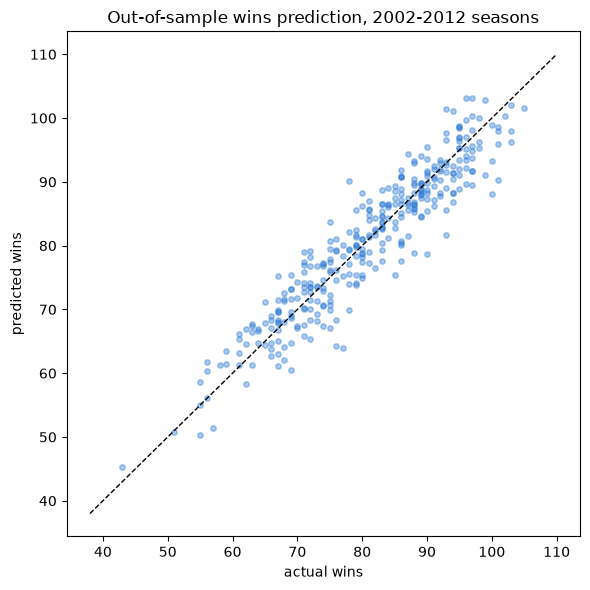

In [4]:
fig, ax = plt.subplots(figsize = (6, 6))
ax.scatter(test.W, wins_pred, alpha = 0.4, s = 15, color = '#2a78d6')
lims = [test.W.min() - 5, test.W.max() + 5]
ax.plot(lims, lims, 'k--', linewidth = 1)
ax.set_xlabel('actual wins'); ax.set_ylabel('predicted wins')
ax.set_title('Out-of-sample wins prediction, 2002-2012 seasons')
plt.tight_layout()
plt.savefig('outputs/wins_prediction.png', dpi = 120)
plt.show()

The Wins model, fit only on data through 2001 and never shown a
single post-2002 season during training, still predicts out-of-sample
wins to within a few games on average, a real out-of-sample validation
of the core Moneyball insight (run differential predicts wins) that the
original notebook's hand-computed single-team check never actually
demonstrated.

In [5]:
oakland_2002 = baseball[(baseball.Team == 'OAK') & (baseball.Year == 2002)]
oakland_2002[['Team', 'Year', 'RS', 'RA', 'W', 'OBP', 'SLG']]

,Team,Year,RS,RA,W,OBP,SLG
320,OAK,2002,800,654,103,0.339,0.432


In [6]:
oak_rs_pred = runs_model.predict(oakland_2002[['OBP', 'SLG']])[0]
oak_w_pred = wins_model.predict(pd.DataFrame({'RD': [oak_rs_pred - oakland_2002.RA.values[0]]}))[0]
print(f'predicted 2002 A\'s runs scored: {oak_rs_pred:.0f} (actual: {oakland_2002.RS.values[0]})')
print(f'predicted 2002 A\'s wins: {oak_w_pred:.0f} (actual: {oakland_2002.W.values[0]})')

predicted 2002 A's runs scored: 808 (actual: 800)
predicted 2002 A's wins: 97 (actual: 103)


In [7]:
import json, os
os.makedirs('outputs', exist_ok = True)
with open('outputs/model_results.json', 'w') as f:
    json.dump({
        'runs_r2_oos': float(r2_score(test.RS, runs_pred)),
        'runs_mae_oos': float(mean_absolute_error(test.RS, runs_pred)),
        'wins_r2_oos': float(r2_score(test.W, wins_pred)),
        'wins_mae_oos': float(mean_absolute_error(test.W, wins_pred)),
        'baseline_mae': float(mean_absolute_error(test.W, baseline_pred)),
    }, f, indent = 2)